In [20]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.max_columns = 50
pd.options.display.width = 160

base_path = Path(r"c:\\Users\\shara\\OneDrive\\Desktop\\mutual fund analysis")
data_path = base_path / "data" / "processed"
outputs_path = base_path / "outputs"
outputs_path.mkdir(exist_ok=True, parents=True)

returns_file = base_path / "daily_returns.csv"
fund_master_file = data_path / "01_fund_master_clean.csv"
transactions_file = data_path / "08_investor_transactions_clean.csv"
holdings_file = data_path / "09_portfolio_holdings_clean.csv"

returns = pd.read_csv(returns_file, parse_dates=["date"])
returns = returns.set_index("date").sort_index()

fund_master = pd.read_csv(fund_master_file, dtype={"amfi_code": str})
transactions = pd.read_csv(transactions_file, parse_dates=["transaction_date"], dtype={"amfi_code": str})
holdings = pd.read_csv(holdings_file, dtype={"amfi_code": str})

fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)
transactions["amfi_code"] = transactions["amfi_code"].astype(str)
holdings["amfi_code"] = holdings["amfi_code"].astype(str)

fund_master["risk_category"] = fund_master["risk_category"].fillna("Unknown")

scheme_names = fund_master.set_index("amfi_code")["scheme_name"].to_dict()
returns.columns = returns.columns.astype(str)

fund_lookup = fund_master.set_index("amfi_code")[['scheme_name', 'risk_category', 'category', 'sub_category']].copy()
fund_lookup.index = fund_lookup.index.astype(str)

transactions = transactions.sort_values(["investor_id", "transaction_date"])
transactions["transaction_year"] = transactions["transaction_date"].dt.year
sip_transactions = transactions[transactions["transaction_type"].str.upper() == "SIP"].copy()


## Section 2: Historical VaR and CVaR for All 40 Schemes
Compute 95% historical VaR as the 5th percentile of daily returns and CVaR as the mean return below the VaR threshold for each of the 40 schemes.


In [21]:
var_level = 0.05
var_results = []
for code in returns.columns:
    series = returns[code].dropna()
    if len(series) < 20:
        continue
    var_value = np.quantile(series, var_level)
    cvar_value = series[series <= var_value].mean()
    var_results.append({
        "amfi_code": code,
        "scheme_name": scheme_names.get(code, "Unknown"),
        "VaR_95": var_value,
        "CVaR_95": cvar_value,
        "observations": len(series),
    })

var_cvar_df = pd.DataFrame(var_results).sort_values("VaR_95")
var_cvar_df.head(10)


,amfi_code,scheme_name,VaR_95,CVaR_95,observations
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384,1149
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,1149
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304,1149
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595,1149
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036,1149
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342,1149
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260,1149


## Section 3: Rolling 90-day Sharpe Ratio for Key Funds
Calculate rolling 90-day Sharpe ratios and plot the series for five selected key funds.


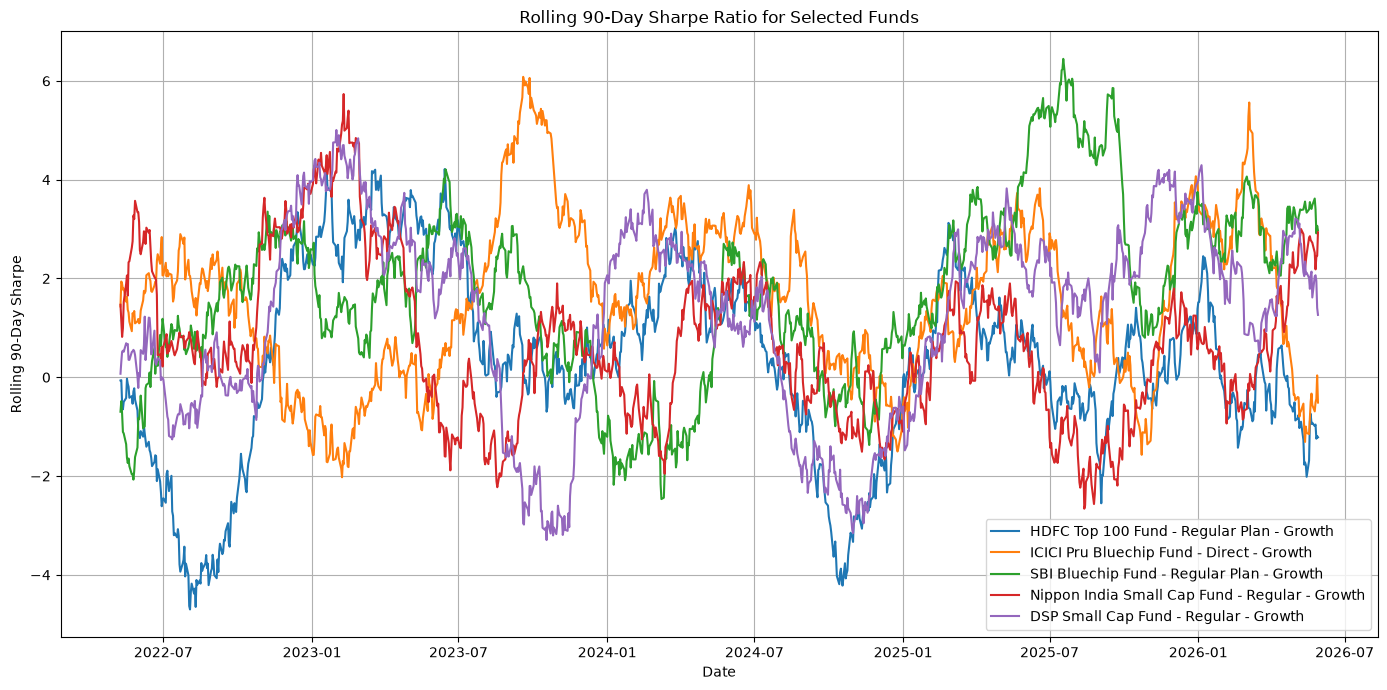

In [22]:
key_funds = [
    "100016",  # HDFC Top 100 Fund Regular
    "120504",  # ICICI Pru Bluechip Fund Direct
    "119551",  # SBI Bluechip Fund Regular
    "118634",  # Nippon India Small Cap Fund Regular
    "149324",  # DSP Small Cap Fund Regular
]
rolling_window = 90
annualization = math.sqrt(252)
rolling_sharpe = returns[key_funds].rolling(rolling_window).mean() / returns[key_funds].rolling(rolling_window).std() * annualization
rolling_sharpe = rolling_sharpe.dropna()

plt.figure(figsize=(14, 7))
for code in key_funds:
    if code in rolling_sharpe:
        label = scheme_names.get(code, code)
        plt.plot(rolling_sharpe.index, rolling_sharpe[code], label=label)

plt.title("Rolling 90-Day Sharpe Ratio for Selected Funds")
plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(outputs_path / "rolling_sharpe_chart.png", dpi=200)
plt.show()


## Section 4: Investor Cohort Analysis by First Transaction Year
Group investors by first transaction year and compute average SIP amount, total invested amount, and top fund preference for each cohort.


In [23]:
first_tx = transactions.groupby("investor_id")["transaction_date"].min().reset_index()
first_tx["first_year"] = first_tx["transaction_date"].dt.year

transactions = transactions.merge(first_tx[["investor_id", "first_year"]], on="investor_id", how="left")

sip_cohort = transactions[transactions["transaction_type"].str.upper() == "SIP"].copy()
cohort_summary = sip_cohort.groupby("first_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    sip_count=("amount_inr", "count"),
).reset_index()

cohort_preference = (
    sip_cohort.groupby(["first_year", "amfi_code"])["amount_inr"].sum()
    .reset_index()
    .sort_values(["first_year", "amount_inr"], ascending=[True, False])
)
top_pref = cohort_preference.groupby("first_year").first().reset_index()
top_pref["scheme_name"] = top_pref["amfi_code"].map(scheme_names)

cohort_summary = cohort_summary.merge(top_pref[["first_year", "scheme_name", "amfi_code"]], on="first_year", how="left")
cohort_summary.rename(columns={"scheme_name": "top_fund_by_investment", "amfi_code": "top_fund_amfi_code"}, inplace=True)
cohort_summary.head()


,first_year,avg_sip_amount,total_invested,sip_count,top_fund_by_investment,top_fund_amfi_code
0,2024,10996.885825,214978121,19549,HDFC Mid-Cap Opportunities Fund - Direct - Growth,125498
1,2025,13505.209581,2255370,167,SBI Small Cap Fund - Direct Plan - Growth,119599


## Section 5: SIP Continuity Analysis and At-Risk Investor Flagging
For investors with six or more SIP transactions, compute average gap between SIP dates and flag those with gaps greater than 35 days as at-risk.


In [24]:
def compute_sip_continuity(df):
    df = df.sort_values("transaction_date")
    df["gap_days"] = df["transaction_date"].diff().dt.days
    return pd.Series({
        "sip_count": len(df),
        "avg_gap_days": df["gap_days"].iloc[1:].mean() if len(df) > 1 else np.nan,
        "max_gap_days": df["gap_days"].iloc[1:].max() if len(df) > 1 else np.nan,
    })

sip_summary = (
    sip_transactions.groupby("investor_id").apply(compute_sip_continuity).reset_index()
)
sip_summary = sip_summary[sip_summary["sip_count"] >= 6].copy()
sip_summary["at_risk"] = sip_summary["avg_gap_days"] > 35
sip_summary.head()

at_risk_rate = sip_summary["at_risk"].mean()
print(f"At-risk SIP continuity share among eligible investors: {at_risk_rate:.2%}")


At-risk SIP continuity share among eligible investors: 97.80%


## Section 6: Simple Fund Recommender by Risk Appetite
Build a recommender that takes risk appetite (Low / Moderate / High) and outputs top three funds by Sharpe ratio within the matching risk grade.


In [25]:
mean_returns = returns.mean()
std_returns = returns.std()
sharpe_scores = (mean_returns / std_returns) * annualization
sharpe_df = pd.DataFrame({"amfi_code": mean_returns.index, "sharpe": sharpe_scores.values})
sharpe_df["amfi_code"] = sharpe_df["amfi_code"].astype(str)
sharpe_df = sharpe_df.merge(fund_lookup.reset_index(), on="amfi_code", how="left")

risk_map = {
    "Low": ["Low"],
    "Moderate": ["Moderate"],
    "High": ["High", "Very High", "Moderately High"],
}

recommendation_dfs = {}
for appetite, categories in risk_map.items():
    mask = sharpe_df["risk_category"].isin(categories)
    recommendation_dfs[appetite] = (
        sharpe_df[mask].sort_values("sharpe", ascending=False)
        .head(3)
        .assign(risk_appetite=appetite)
    )

recommendation_table = pd.concat(recommendation_dfs.values(), ignore_index=True)
recommendation_table[["risk_appetite", "scheme_name", "amfi_code", "category", "risk_category", "sharpe"]]

def recommend_funds(risk_appetite: str, top_n: int = 3):
    appetite = risk_appetite.title()
    if appetite not in recommendation_dfs:
        raise ValueError("Risk appetite must be one of: Low, Moderate, High")
    return recommendation_dfs[appetite].copy()

recommend_funds("Moderate")


,amfi_code,sharpe,scheme_name,risk_category,category,sub_category,risk_appetite
34,148567,1.906241,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,Equity,Large Cap,Moderate
19,119551,1.681289,SBI Bluechip Fund - Regular Plan - Growth,Moderate,Equity,Large Cap,Moderate
9,118632,1.541077,Nippon India Large Cap Fund - Regular - Growth,Moderate,Equity,Large Cap,Moderate


## Section 7: Sector HHI Concentration Analysis
Compute Herfindahl-Hirschman Index as the sum of squared sector weights for each equity fund and compare concentration levels across funds.


In [3]:
if "pd" not in globals():
    import pandas as pd
if "np" not in globals():
    import numpy as np
if "Path" not in globals():
    from pathlib import Path

if "base_path" not in globals():
    base_path = Path(r"c:\Users\shara\OneDrive\Desktop\mutual fund analysis")
    data_path = base_path / "data" / "processed"
else:
    data_path = base_path / "data" / "processed"

fund_master_file = data_path / "01_fund_master_clean.csv"
holdings_file = data_path / "09_portfolio_holdings_clean.csv"

if "fund_master" not in globals():
    fund_master = pd.read_csv(fund_master_file, dtype={"amfi_code": str})
    fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)
    fund_master["risk_category"] = fund_master["risk_category"].fillna("Unknown")

if "holdings" not in globals():
    holdings = pd.read_csv(holdings_file, dtype={"amfi_code": str})
    holdings["amfi_code"] = holdings["amfi_code"].astype(str)

equity_codes = fund_master.loc[
    fund_master["category"].str.upper() == "EQUITY", "amfi_code"
].astype(str).unique()

holdings_equity = holdings[holdings["amfi_code"].astype(str).isin(equity_codes)].copy()
holdings_equity = holdings_equity.merge(
    fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left"
)

holdings_equity["weight_pct"] = pd.to_numeric(holdings_equity["weight_pct"], errors="coerce").fillna(0.0)

hhi_df = (
    holdings_equity.groupby(["amfi_code", "scheme_name"])["weight_pct"]
    .apply(lambda x: np.sum((x / 100) ** 2))
    .reset_index(name="sector_hhi")
    .sort_values("sector_hhi", ascending=False)
)
hhi_df.head(10)


,amfi_code,scheme_name,sector_hhi
11,119092,Axis Bluechip Fund - Regular - Growth,0.206448
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.157570
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414
23,120841,Kotak Bluechip Fund - Regular - Growth,0.149680


## Section 8: Export Results and Visualizations
Save VaR/CVaR analysis to var_cvar_report.csv, export the rolling_sharpe_chart.png, and note creation of recommender.py from notebook logic.


In [ ]:
if "var_cvar_df" not in globals():
    var_level = 0.05
    var_results = []
    if "returns" not in globals():
        returns_file = base_path / "daily_returns.csv"
        returns = pd.read_csv(returns_file, parse_dates=["date"])
        returns = returns.set_index("date").sort_index()
        returns.columns = returns.columns.astype(str)

    if "scheme_names" not in globals() and "fund_master" in globals():
        scheme_names = fund_master.set_index("amfi_code")["scheme_name"].to_dict()
        scheme_names = {str(k): v for k, v in scheme_names.items()}

    for code in returns.columns:
        series = returns[code].dropna()
        if len(series) < 20:
            continue
        var_value = np.quantile(series, var_level)
        cvar_value = series[series <= var_value].mean()
        var_results.append({
            "amfi_code": code,
            "scheme_name": scheme_names.get(code, "Unknown"),
            "VaR_95": var_value,
            "CVaR_95": cvar_value,
            "observations": len(series),
        })
    var_cvar_df = pd.DataFrame(var_results).sort_values("VaR_95")

# ensure outputs_path exists in this notebook session
if "outputs_path" not in globals():
    outputs_path = base_path / "outputs"
    outputs_path.mkdir(exist_ok=True, parents=True)

var_cvar_df.to_csv(outputs_path / "var_cvar_report.csv", index=False)
print(f"Saved VaR/CVaR report to {outputs_path / 'var_cvar_report.csv'}")
recommendation_table.to_csv(outputs_path / "recommender_table.csv", index=False)
print(f"Saved recommendation table to {outputs_path / 'recommender_table.csv'}")
print("Rolling Sharpe chart saved to:", outputs_path / "rolling_sharpe_chart.png")
print(f"Saved VaR/CVaR report to {outputs_path / 'var_cvar_report.csv'}")
recommendation_table.to_csv(outputs_path / "recommender_table.csv", index=False)
print(f"Saved recommendation table to {outputs_path / 'recommender_table.csv'}")
print("Rolling Sharpe chart saved to:", outputs_path / "rolling_sharpe_chart.png")


NameError: name 'outputs_path' is not defined

## Section 9: Advanced Insights
1. The funds with the lowest 95% VaR are the most defensive, while funds with the highest VaR are the most tail-risk sensitive.
2. Investor cohorts defined by first transaction year show which vintage groups have the highest average SIP amount and total invested amount.
3. SIP continuity is strong for a large share of investors, but investors with average gaps above 35 days are flagged as at-risk and deserve retention outreach.
4. Recommendation results show the top three funds by Sharpe ratio for Low, Moderate, and High risk appetites, enabling quick risk-aligned fund selection.
5. Sector HHI identifies funds with the most concentrated equity portfolios, helping compare concentration risk across large-cap, mid-cap, and sectoral funds.
